# Generative adversarial networks

### Two networks with opposing objectives, and no loss you can trust

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How a generator and a discriminator define a game rather than an objective, what the minimax value function says and what the optimal discriminator turns it into, why the generator's original loss goes flat exactly when it is losing and what the non-saturating form fixes, why GAN losses do not tell you whether training is going well when every other model in this book has a loss that does, what mode collapse is and how to count it instead of describing it, and what label smoothing and a slower generator buy when you measure them across seeds |
| **You should already know** | [Variational autoencoders](../02-variational-autoencoders/) · [The PyTorch training loop](../../07-neural-networks/03-the-same-net-in-pytorch/) · [Maximum likelihood](../../04-probability/02-maximum-likelihood/) |
| **Dataset** | A 2-D mixture of eight Gaussians on a ring, generated with numpy, for everything that gets measured; Fashion-MNIST (12,000 images, the same subsample as [10-01](../01-autoencoders/) and [10-02](../02-variational-autoencoders/)) for the closing demonstration |
| **Runtime** | Five to seven minutes on a laptop CPU, two to three on a GPU. The image GAN at the end stops on a wall-clock cap rather than after a fixed number of epochs, so it never runs away |
| **Next** | [10-04 Diffusion models](../04-diffusion-models/) |

---

## 1. Two networks, opposing goals

[10-02](../02-variational-autoencoders/) finished with a model that works and a
complaint about what it produces. A variational autoencoder writes down a
likelihood, bounds it, and maximises the bound. Every choice it makes traces back
to one number going up. The price is in the reconstruction term: a per-pixel
log-likelihood, and when the decoder is unsure whether an edge lands on one pixel
or its neighbour, the cheapest answer is half an edge on each. Blur is what
averaging looks like, and no extra capacity removes it.

A generative adversarial network attacks that from the opposite side. It never
writes down a probability for anything. There is no likelihood, no bound, no
density. Instead there are two networks:

```
  z ~ N(0, I) ──► generator ──► fake sample ─┐
                                             ├─► discriminator ──► one number
  training set ─────────────► real sample ───┘                     per input

  the discriminator wants that number to say "real" for real inputs
  and "fake" for generated ones

  the generator wants it to say "real" for generated ones
```

The discriminator is an ordinary binary classifier, trained with ordinary cross
entropy. The generator never sees the training data. It only ever receives
gradient through the discriminator, which is to say it is told "this is the
direction that would have made me more convinced" and moves that way.

Written as one expression, with $D(x)$ the discriminator's probability that $x$
is real and $G(z)$ the generator's output:

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}}\left[\log D(x)\right] + \mathbb{E}_{z \sim p_z}\left[\log\left(1 - D(G(z))\right)\right]$$

Two facts about that expression are worth having before any code. Hold the
generator fixed and ask what the best possible discriminator does. Since the
integrand is $p_{\text{data}}(x)\log D(x) + p_g(x)\log(1 - D(x))$ pointwise and
$a\log t + b\log(1-t)$ is maximised at $t = a/(a+b)$:

$$D^\star(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}$$

Substitute that back and the value function becomes
$2\,D_{\mathrm{JS}}(p_{\text{data}} \,\|\, p_g) - \log 4$. So the generator, facing
a perfect discriminator, is minimising a genuine divergence between its
distribution and the data's, and the minimum sits where the two coincide. That
is the theory, and it is clean.

What it assumes is that the discriminator is optimal at every moment. In
practice both networks take one small gradient step at a time, so neither term
is ever at its optimum, and the guarantee evaporates. Almost everything awkward
about GANs comes out of that gap. This notebook is mostly about the awkward part.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")

torch 2.11.0+cu128 on cuda


### A problem where I can check the answer

Image GANs are slow, and worse, they are hard to score. If a batch of generated
shoes looks reasonable, I still cannot say what fraction of the real data the
model is capable of producing, and that fraction is the quantity this notebook
cares about most.

So the measured work happens on a toy problem where the true distribution is
known exactly: **eight Gaussians with their centres spaced evenly around a
circle**. This is the standard testbed for the failure mode in section 4, it
trains in seconds, and it lets me count something instead of squinting at
something. A Fashion-MNIST GAN arrives at the end as a demonstration, with the
expectations set honestly before it runs.

Two measurements, defined here and used everywhere below.

**Coverage** is how many of the eight modes the generator actually reaches. A
generated point counts as landing on a mode if it falls within three standard
deviations of that centre, and a mode counts as covered if at least one per cent
of the batch lands on it. Both thresholds are arbitrary, which is why they are
written down rather than buried.

**Quality** is the share of generated points that land on any mode at all. A
generator that spreads points evenly over the whole plane covers all eight modes
by the definition above while producing mostly rubbish, and the quality number is
what catches that.

In [2]:
N_MODES = 8
RADIUS = 2.0
SPREAD = 0.10          # standard deviation of each Gaussian, in the same units
NOISE = 8              # size of the generator's input vector
N_EVAL = 2000          # points drawn from the generator at every checkpoint

_angles = 2 * np.pi * np.arange(N_MODES) / N_MODES
CENTRES = np.stack([RADIUS * np.cos(_angles), RADIUS * np.sin(_angles)], axis=1)


def sample_ring(n, rng):
    """n draws from an equal mixture of the eight Gaussians."""
    which = rng.integers(0, N_MODES, size=n)
    return (CENTRES[which] + SPREAD * rng.standard_normal((n, 2))).astype(np.float32)


def mode_stats(points, tol=3.0, min_share=0.01):
    """Coverage and quality for a cloud of generated points.

    Returns the number of modes covered, the share of points that landed on some
    mode, and the per-mode counts. The counts are what section 4 prints when
    "how many modes" stops being a fine enough question.
    """
    distances = np.linalg.norm(points[:, None, :] - CENTRES[None, :, :], axis=2)
    nearest, closest = distances.argmin(axis=1), distances.min(axis=1)
    on_mode = closest < tol * SPREAD
    counts = np.bincount(nearest[on_mode], minlength=N_MODES)
    return {"covered": int((counts >= min_share * len(points)).sum()),
            "quality": float(on_mode.mean()),
            "counts": counts}


rng = np.random.default_rng(SEED)
real_cloud = sample_ring(N_EVAL, rng)
real_stats = mode_stats(real_cloud)

print(f"real data      : {real_stats['covered']} of {N_MODES} modes covered, "
      f"quality {real_stats['quality']:.3f}")
print("share of real points per mode:",
      np.round(real_stats["counts"] / N_EVAL, 3))

# A generator that has collapsed onto one mode, hand-built, so the metric can be
# seen scoring the thing it exists to catch.
one_mode = (CENTRES[0] + SPREAD * rng.standard_normal((N_EVAL, 2))).astype(np.float32)
scattered = (3.0 * rng.standard_normal((N_EVAL, 2))).astype(np.float32)
print(f"\nstuck on one mode: covered {mode_stats(one_mode)['covered']}, "
      f"quality {mode_stats(one_mode)['quality']:.3f}")
print(f"noise everywhere : covered {mode_stats(scattered)['covered']}, "
      f"quality {mode_stats(scattered)['quality']:.3f}")

real data      : 8 of 8 modes covered, quality 0.994
share of real points per mode: [0.11  0.118 0.122 0.125 0.131 0.126 0.13  0.13 ]

stuck on one mode: covered 1, quality 0.988
noise everywhere : covered 0, quality 0.030


The two failure rows are the reason both numbers get reported together
throughout. Neither one alone separates a good generator from a bad one.

Now the networks. They are deliberately small and deliberately ordinary: two
hidden layers each, no normalisation, no tricks. Everything interesting in this
notebook comes from the training procedure, not from the architecture.

One implementation detail that matters more than it looks. The discriminator
ends in a plain linear layer producing a **logit**, not a sigmoid, and the
sigmoid lives inside `BCEWithLogitsLoss`. That is the numerically stable
arrangement everywhere, and here it also keeps the two generator losses in
section 2 written in terms of the same quantity so they can be compared.

In [3]:
class Generator(nn.Module):
    """Noise in, a sample out. No probability is written down anywhere."""

    def __init__(self, n_out=2, noise=NOISE, width=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise, width), nn.ReLU(),
            nn.Linear(width, width), nn.ReLU(),
            nn.Linear(width, n_out),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """A binary classifier ending in a logit. LeakyReLU so it keeps passing
    gradient back to the generator in the half-space where it is confident."""

    def __init__(self, n_in=2, width=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, width), nn.LeakyReLU(0.2),
            nn.Linear(width, width), nn.LeakyReLU(0.2),
            nn.Linear(width, 1),
        )

    def forward(self, x):
        return self.net(x)


count = lambda m: sum(p.numel() for p in m.parameters())
print(f"generator     : {count(Generator()):,} parameters, "
      f"{NOISE} noise inputs -> 2 coordinates")
print(f"discriminator : {count(Discriminator()):,} parameters, "
      f"2 coordinates -> 1 logit")

generator     : 17,922 parameters, 8 noise inputs -> 2 coordinates
discriminator : 17,025 parameters, 2 coordinates -> 1 logit


## 2. The saturating loss and the fix

Read the generator's half of the minimax objective again:

$$\min_G \; \mathbb{E}_z\left[\log\left(1 - D(G(z))\right)\right]$$

At the start of training the generator produces obvious rubbish and the
discriminator sorts it out immediately, so $D(G(z))$ sits near zero. Look at what
happens to the gradient there. With $t$ the discriminator's logit and
$D = \sigma(t)$:

$$\frac{\partial}{\partial t}\log\left(1 - \sigma(t)\right) = -\sigma(t) = -D(G(z))$$

The gradient the generator receives is proportional to $D(G(z))$ itself. The
worse the generator is doing, the smaller its gradient. The loss is flattest
precisely where the model needs to move most, which is backwards from how a loss
should behave.

The fix in the original paper is to stop minimising $\log(1 - D(G(z)))$ and start
maximising $\log D(G(z))$ instead, or equivalently to minimise $-\log D(G(z))$:

$$\frac{\partial}{\partial t}\left[-\log \sigma(t)\right] = \sigma(t) - 1 = D(G(z)) - 1$$

Now the gradient is largest when $D(G(z))$ is near zero. Both forms have their
optimum in the same place and both push the generator the same way; they differ
only in how hard they push at each point. This is the **non-saturating** loss,
and it is what every implementation uses, whatever the paper's equation says.

In code it is one line, and a pleasant one: minimising $-\log D(G(z))$ is exactly
binary cross entropy on the generated batch with the labels flipped to "real".

In [4]:
logits = torch.tensor([-7.0, -5.0, -3.0, -1.0, 0.0, 1.0], requires_grad=True)

saturating = torch.log1p(-torch.sigmoid(logits)).sum()      # log(1 - D)
non_saturating = -torch.log(torch.sigmoid(logits)).sum()    # -log D

grad_sat = torch.autograd.grad(saturating, logits, retain_graph=True)[0]
grad_ns = torch.autograd.grad(non_saturating, logits)[0]

gradients = pd.DataFrame({
    "D(G(z))": torch.sigmoid(logits).detach().numpy(),
    "log(1-D) gradient": grad_sat.numpy(),
    "-log D gradient": grad_ns.numpy(),
    "how much larger": (grad_ns.abs() / grad_sat.abs()).numpy(),
})
print("gradient with respect to the discriminator's logit, per sample:")
print(gradients.round(4).to_string(index=False))
print("\nthe first rows are the regime at the start of training, where the")
print("discriminator is winning and the generator most needs to move")

gradient with respect to the discriminator's logit, per sample:
 D(G(z))  log(1-D) gradient  -log D gradient  how much larger
  0.0009            -0.0009          -0.9991      1096.633301
  0.0067            -0.0067          -0.9933       148.413193
  0.0474            -0.0474          -0.9526        20.085501
  0.2689            -0.2689          -0.7311         2.718300
  0.5000            -0.5000          -0.5000         1.000000
  0.7311            -0.7311          -0.2689         0.367900

the first rows are the regime at the start of training, where the
discriminator is winning and the generator most needs to move


The table is arithmetic, so it settles the point on its own. Whether the
difference shows up in training is a separate question, and the way to find out
is to run both.

One design choice in that experiment. Saturation bites when the discriminator is
winning, so I put both runs in that situation on purpose by giving the
discriminator a head start: a few hundred updates on its own, against an
untrained generator, before the generator is allowed to move at all. Both runs
get the identical head start, the identical seed and the identical everything
else. The only difference is the sign convention in three lines of the loss.

Here is the training function the rest of the notebook uses. Every knob this
notebook varies is an argument, and the defaults are the plain version: equal
learning rates, hard labels, one generator update per discriminator update.

In [5]:
bce = nn.BCEWithLogitsLoss()


@torch.no_grad()
def generated_points(G, z):
    """Generator output as a numpy array, with the model in eval mode."""
    G.eval()
    points = G(z).cpu().numpy()
    G.train()
    return points


def train_ring(steps=3000, g_lr=1e-3, d_lr=1e-3, beta1=0.5, smooth=1.0,
               g_steps=1, warmup=0, batch=256, seed=SEED, every=50,
               saturating=False, snapshot_at=()):
    """One GAN run on the ring.

    `smooth` is the label the discriminator is asked to produce for real points,
    so 1.0 is the usual hard target and anything below it is one-sided label
    smoothing. `g_steps` is how many generator updates happen per discriminator
    update, and setting it above 1 is how section 4 breaks training on purpose.
    `warmup` runs discriminator-only updates first.

    Returns both networks, the per-step losses, a checkpoint table of coverage
    and quality, and snapshots of the generated cloud at the requested steps.
    """
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    G, D = Generator().to(device), Discriminator().to(device)
    opt_g = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(beta1, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(beta1, 0.999))

    # The same noise at every checkpoint, so a change in the measured cloud is a
    # change in the generator and never a change in the draw.
    fixed_z = torch.randn(N_EVAL, NOISE, device=device)

    losses, checks, snapshots = [], [], {}
    recent_g, recent_d = [], []

    def discriminator_step():
        real = torch.from_numpy(sample_ring(batch, rng)).to(device)
        with torch.no_grad():
            fake = G(torch.randn(batch, NOISE, device=device))
        out_real, out_fake = D(real), D(fake)
        loss = (bce(out_real, torch.full_like(out_real, smooth))
                + bce(out_fake, torch.zeros_like(out_fake)))
        opt_d.zero_grad(); loss.backward(); opt_d.step()
        return loss.item()

    for _ in range(warmup):
        discriminator_step()

    for step in range(steps + 1):
        if step in snapshot_at:
            snapshots[step] = generated_points(G, fixed_z)
        if step % every == 0:
            stats = mode_stats(generated_points(G, fixed_z))
            checks.append({
                "step": step,
                "covered": stats["covered"],
                "quality": stats["quality"],
                "generator loss": float(np.mean(recent_g)) if recent_g else np.nan,
                "discriminator loss": float(np.mean(recent_d)) if recent_d else np.nan,
            })
            recent_g, recent_d = [], []
        if step == steps:
            break

        d_loss = discriminator_step()

        for _ in range(g_steps):
            out = D(G(torch.randn(batch, NOISE, device=device)))
            if saturating:
                # log(1 - D(G(z))), the objective as originally written
                g_loss = -bce(out, torch.zeros_like(out))
            else:
                # -log D(G(z)), the form everybody actually runs
                g_loss = bce(out, torch.ones_like(out))
            opt_g.zero_grad(); g_loss.backward(); opt_g.step()

        losses.append({"step": step, "generator": g_loss.item(),
                       "discriminator": d_loss})
        recent_g.append(g_loss.item()); recent_d.append(d_loss)

    return G, D, pd.DataFrame(losses), pd.DataFrame(checks), snapshots

In [6]:
started = time.perf_counter()
comparison = []
for name, is_saturating in [("saturating, log(1 - D)", True),
                            ("non-saturating, -log D", False)]:
    _, _, _, checks_i, _ = train_ring(steps=1200, warmup=200, every=100,
                                      saturating=is_saturating)
    tail = checks_i[checks_i["step"] >= 800]
    comparison.append({
        "generator loss": name,
        "modes covered, final": int(checks_i["covered"].iloc[-1]),
        "modes covered, last third": tail["covered"].mean(),
        "quality, last third": tail["quality"].mean(),
    })

print("1,200 generator updates each, after 200 discriminator-only warmup steps:")
print(pd.DataFrame(comparison).round(3).to_string(index=False))
print(f"\nboth runs in {time.perf_counter() - started:.0f} seconds on {device}")

1,200 generator updates each, after 200 discriminator-only warmup steps:
        generator loss  modes covered, final  modes covered, last third  quality, last third
saturating, log(1 - D)                     8                        8.0                0.537
non-saturating, -log D                     8                        8.0                0.675

both runs in 25 seconds on cuda


Read the coverage and quality columns against each other. The gradient table
above is the reliable half of the argument, because it is arithmetic; this is one
run of a stochastic process with one seed, shown as it came out. The reason to
run it anyway is that a gradient being ninety times smaller is only interesting
if it changes what the model ends up doing, and a table nobody checks is a claim
rather than a result.

Everything from here on uses the non-saturating form.

### The main run

Now a plain GAN on the ring, with nothing switched on: equal learning rates, hard
labels, one update each, three thousand steps. Snapshots at four points along the
way, so the figure shows the process rather than the outcome.

In [7]:
MAIN_STEPS = 3000
SNAPSHOTS = (0, 150, 600, MAIN_STEPS)

started = time.perf_counter()
G_main, D_main, main_losses, main_checks, main_snaps = train_ring(
    steps=MAIN_STEPS, every=50, snapshot_at=SNAPSHOTS)
elapsed = time.perf_counter() - started

final = main_checks.iloc[-1]
print(f"{MAIN_STEPS:,} steps in {elapsed:.0f} seconds on {device}")
print(f"final checkpoint: {int(final['covered'])} of {N_MODES} modes covered, "
      f"quality {final['quality']:.3f}")
print(f"best coverage seen at any checkpoint: {int(main_checks['covered'].max())}, "
      f"worst after step 500: "
      f"{int(main_checks[main_checks['step'] > 500]['covered'].min())}")

3,000 steps in 24 seconds on cuda
final checkpoint: 8 of 8 modes covered, quality 0.941
best coverage seen at any checkpoint: 8, worst after step 500: 8


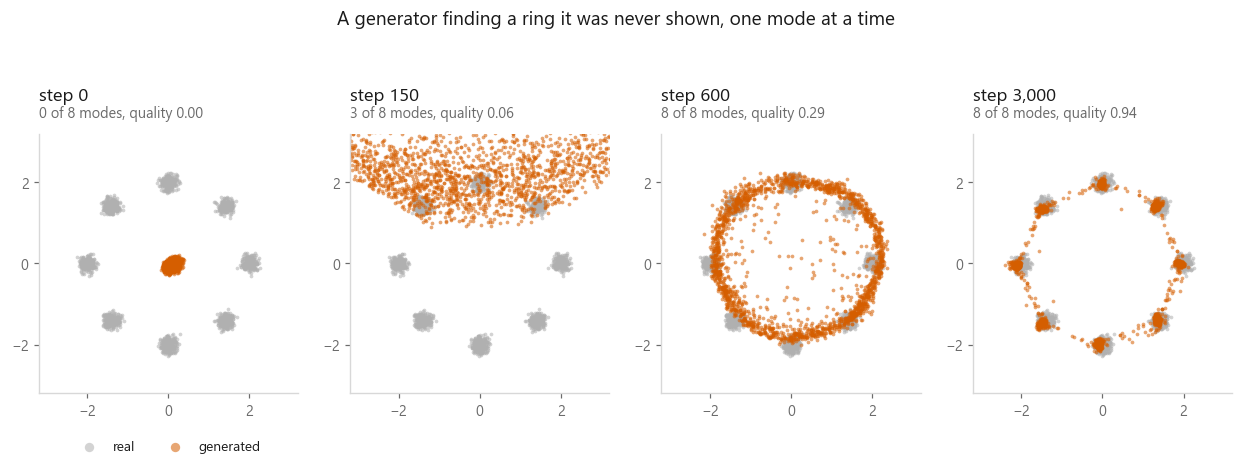

In [8]:
fig, axes = plt.subplots(1, len(SNAPSHOTS), figsize=(14.0, 3.8))
for ax, step in zip(axes, SNAPSHOTS):
    points = main_snaps[step]
    stats = mode_stats(points)
    ax.scatter(real_cloud[:, 0], real_cloud[:, 1], s=6, linewidths=0,
               color=style.NEUTRAL, alpha=0.55, label="real")
    ax.scatter(points[:, 0], points[:, 1], s=6, linewidths=0,
               color=style.HIGHLIGHT, alpha=0.55, label="generated")
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
    ax.set_aspect("equal")
    ax.set_xticks([-2, 0, 2]); ax.set_yticks([-2, 0, 2])
    ax.grid(False)
    style.title(ax, f"step {step:,}",
                f"{stats['covered']} of {N_MODES} modes, "
                f"quality {stats['quality']:.2f}")

axes[0].legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=2,
               fontsize=9, markerscale=2.5)
fig.suptitle("A generator finding a ring it was never shown, one mode at a time",
             x=0.5, y=1.10, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-ring-training-stages.png")

The generator starts as a small blob near the origin, because an untrained
network maps a standard normal to something near-linear and centred. It never
sees a real point. The only information reaching it is the discriminator's
opinion, and the ring appears out of that opinion alone.

## 3. The losses do not tell you anything

This is the section that separates GANs from every other model in this book, and
it is worth being blunt about.

For a regression, a classifier, an autoencoder or a variational autoencoder, the
loss is a fixed function. Training reduces it, held-out loss stops reducing when
you have gone too far, and you can early-stop, compare architectures and pick a
checkpoint by reading a number. The whole practice of the previous nine chapters
rests on that.

A GAN has no such number. The generator's loss measures how well it does against
**the discriminator as it currently stands**, and the discriminator is moving.
The generator's loss can fall because the generator improved or because the
discriminator got worse, and nothing in the value distinguishes those. The same
is true in reverse. At the theoretical equilibrium the two are balanced and the
losses sit at fixed values, printed below, which sounds usable until you notice
that a generator producing one mode perfectly and a generator producing all eight
can both hold the discriminator near that point.

Below I plot the two losses from the main run, and then plot the generator's loss
against the coverage measured at the same checkpoints. If the loss were a
training signal in the sense the rest of this book uses the word, the second
panel would be a downward-sloping line.

In [9]:
usable = main_checks.dropna().copy()
settled = usable[usable["step"] >= MAIN_STEPS // 5]     # after the opening transient

print("equilibrium reference values, if the game ever reached its optimum:")
print(f"  discriminator, two cross-entropy terms summed : {2 * np.log(2):.3f}")
print(f"  generator, -log D(G(z))                       : {np.log(2):.3f}")

for label, frame in [("all checkpoints", usable), ("after the first fifth", settled)]:
    if frame["covered"].nunique() < 2:
        print(f"\n{label}: coverage never varied, so a correlation is undefined")
        continue
    pair = frame[["generator loss", "covered"]]
    pearson = pair.corr().iloc[0, 1]
    spearman = pair.rank().corr().iloc[0, 1]
    print(f"\ncorrelation between generator loss and modes covered, {label}:")
    print(f"  Pearson {pearson:+.3f}, Spearman {spearman:+.3f}   "
          f"(a usable early-stopping signal would sit near -1)")

best = settled.loc[settled["generator loss"].idxmin()]
last = settled.iloc[-1]
print(f"\nlowest generator loss after the transient, at step {int(best['step']):,}: "
      f"{best['generator loss']:.3f}, covering {int(best['covered'])} modes")
print(f"the last checkpoint, at step {int(last['step']):,}: "
      f"{last['generator loss']:.3f}, covering {int(last['covered'])} modes")

equilibrium reference values, if the game ever reached its optimum:
  discriminator, two cross-entropy terms summed : 1.386
  generator, -log D(G(z))                       : 0.693

correlation between generator loss and modes covered, all checkpoints:
  Pearson -0.771, Spearman -0.447   (a usable early-stopping signal would sit near -1)

after the first fifth: coverage never varied, so a correlation is undefined

lowest generator loss after the transient, at step 3,000: 0.733, covering 8 modes
the last checkpoint, at step 3,000: 0.733, covering 8 modes


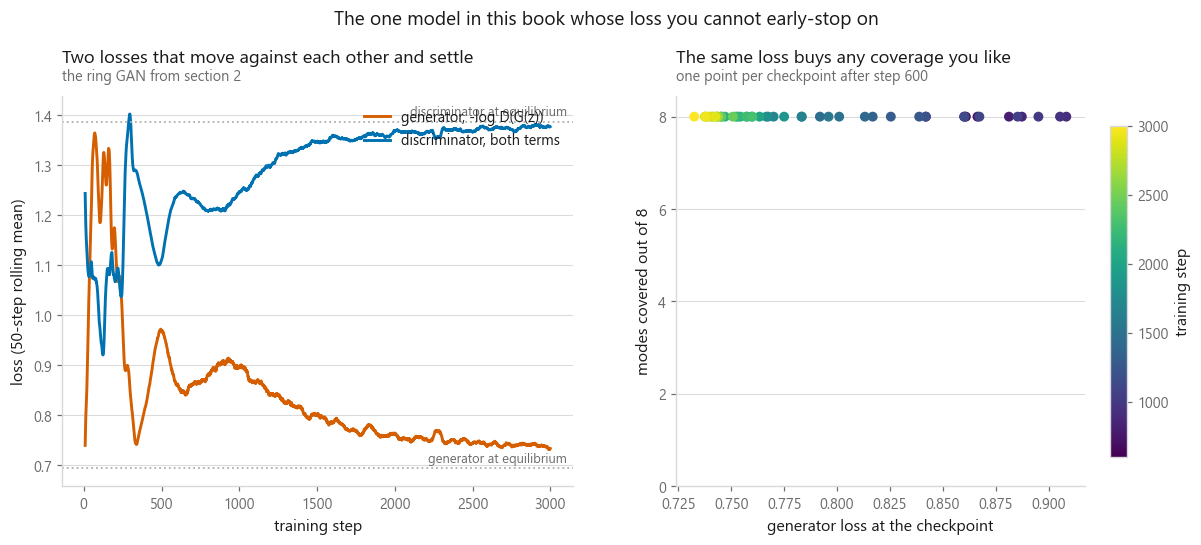

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6))

smoothed = main_losses.set_index("step").rolling(50, min_periods=10).mean()
axes[0].plot(smoothed.index, smoothed["generator"], color=style.HIGHLIGHT,
             label="generator, -log D(G(z))")
axes[0].plot(smoothed.index, smoothed["discriminator"], color=style.PALETTE[0],
             label="discriminator, both terms")
for value, text in [(np.log(2), "generator at equilibrium"),
                    (2 * np.log(2), "discriminator at equilibrium")]:
    axes[0].axhline(value, color=style.NEUTRAL, linestyle=":", linewidth=1.2)
    axes[0].annotate(text, xy=(1.0, value), xycoords=("axes fraction", "data"),
                     xytext=(-4, 4), textcoords="offset points", ha="right",
                     fontsize=8.5, color=style.MUTED)
axes[0].set_xlabel("training step")
axes[0].set_ylabel("loss (50-step rolling mean)")
axes[0].legend(loc="upper right")
style.title(axes[0], "Two losses that move against each other and settle",
            "the ring GAN from section 2")

scatter = axes[1].scatter(settled["generator loss"], settled["covered"],
                          c=settled["step"], cmap="viridis", s=42,
                          marker=style.MARKERS[0], linewidths=0)
axes[1].set_xlabel("generator loss at the checkpoint")
axes[1].set_ylabel("modes covered out of 8")
axes[1].set_yticks(range(0, N_MODES + 1, 2))
fig.colorbar(scatter, ax=axes[1], shrink=0.85, label="training step")
style.title(axes[1], "The same loss buys any coverage you like",
            f"one point per checkpoint after step {MAIN_STEPS // 5:,}")

fig.suptitle("The one model in this book whose loss you cannot early-stop on",
             x=0.5, y=1.05, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-losses-tell-you-nothing.png")

The left panel looks like a training curve and reads like one, which is the trap.
Both losses move toward their equilibrium values and then wobble around them.
Nothing in that picture says whether the generator is producing all eight modes
or one, and the right panel is the same run's answer to that question: a vertical
smear where a downward line would be.

The correlation printed above is the number to argue with. Over the whole run
there is some relationship, because at step zero the generator is untrained and
its loss is high, and any metric correlates with any other metric during a
transient. After the opening fifth the question becomes the real one, which is
whether the loss tells you anything **while training is underway**, when the
choice of when to stop is actually being made.

So what do you do instead? You look at samples. On this problem I can count them,
which is the whole reason the problem is a ring of Gaussians. On images, people
use Fréchet Inception Distance and its relatives, which are sample-based scores
computed from a separate pretrained network, and they use their eyes. The
discipline that carries over from the rest of the book is the discipline of
measuring; what does not carry over is the idea that the training objective is
the thing to measure.

## 4. Mode collapse, counted

Here is the failure the metric was built for.

The generator's job is to produce output the discriminator calls real. Nothing in
that job description says "produce a *variety* of output the discriminator calls
real". If one particular point fools the current discriminator, a generator that
emits that point every time has a perfect score by its own objective. The
discriminator then learns that this point is fake, so the generator moves to
another single point, and the two can circle each other indefinitely with the
generator producing one thing at a time. That is **mode collapse**, and it has no
analogue in supervised learning, because a classifier that outputs one class for
everything is punished by its own loss immediately.

I will cause it rather than describe it. The recipe is to let the generator
outrun the discriminator: three generator updates for every discriminator update,
a generator learning rate twenty times the discriminator's, and Adam's first
momentum coefficient at 0.9 rather than the 0.5 that GAN implementations usually
set. Each of those on its own tilts the game; together they tilt it hard. Against
it I run a version with the opposite settings, which is where section 5's
stabilisers come from.

In [11]:
COLLAPSE_STEPS = 2000

started = time.perf_counter()
_, _, _, unstable_checks, unstable_snaps = train_ring(
    steps=COLLAPSE_STEPS, every=50, snapshot_at=(COLLAPSE_STEPS,),
    g_steps=3, g_lr=4e-3, d_lr=2e-4, beta1=0.9)
_, _, _, stable_checks, stable_snaps = train_ring(
    steps=COLLAPSE_STEPS, every=50, snapshot_at=(COLLAPSE_STEPS,),
    g_lr=5e-4, d_lr=1e-3, beta1=0.5, smooth=0.9)
print(f"two runs in {time.perf_counter() - started:.0f} seconds on {device}")

tail = lambda frame: frame[frame["step"] >= COLLAPSE_STEPS * 2 // 3]
summary = pd.DataFrame([
    {"run": "generator outruns discriminator",
     "modes covered, last third": tail(unstable_checks)["covered"].mean(),
     "quality, last third": tail(unstable_checks)["quality"].mean(),
     "generator loss, last third": tail(unstable_checks)["generator loss"].mean(),
     "discriminator loss, last third": tail(unstable_checks)["discriminator loss"].mean()},
    {"run": "balanced, with smoothing",
     "modes covered, last third": tail(stable_checks)["covered"].mean(),
     "quality, last third": tail(stable_checks)["quality"].mean(),
     "generator loss, last third": tail(stable_checks)["generator loss"].mean(),
     "discriminator loss, last third": tail(stable_checks)["discriminator loss"].mean()},
])
print(summary.round(3).to_string(index=False))

two runs in 59 seconds on cuda
                            run  modes covered, last third  quality, last third  generator loss, last third  discriminator loss, last third
generator outruns discriminator                      0.571                0.169                       0.682                           1.410
       balanced, with smoothing                      8.000                0.797                       1.044                           1.278


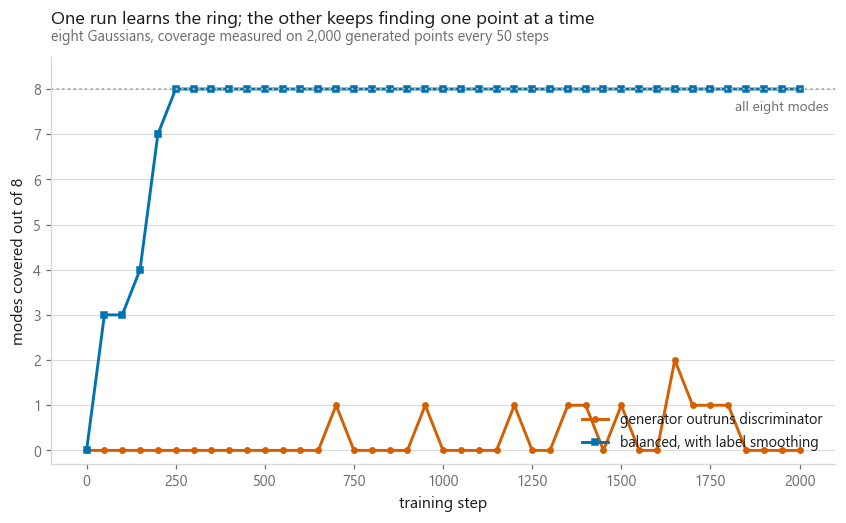

In [12]:
fig, ax = plt.subplots(figsize=(9.2, 4.8))
ax.plot(unstable_checks["step"], unstable_checks["covered"],
        color=style.HIGHLIGHT, marker=style.MARKERS[0], markersize=3.5,
        label="generator outruns discriminator")
ax.plot(stable_checks["step"], stable_checks["covered"],
        color=style.PALETTE[0], marker=style.MARKERS[1], markersize=3.5,
        label="balanced, with label smoothing")
ax.axhline(N_MODES, color=style.NEUTRAL, linestyle=":", linewidth=1.4)
ax.annotate("all eight modes", xy=(1.0, N_MODES), xycoords=("axes fraction", "data"),
            xytext=(-4, -14), textcoords="offset points", ha="right",
            fontsize=9, color=style.MUTED)
ax.set_xlabel("training step")
ax.set_ylabel("modes covered out of 8")
ax.set_yticks(range(0, N_MODES + 1))
ax.set_ylim(-0.3, N_MODES + 0.7)
ax.legend(loc="lower right")
style.title(ax, "One run learns the ring; the other keeps finding one point at a time",
            "eight Gaussians, coverage measured on 2,000 generated points every 50 steps")
style.save(fig, FIG / "fig-03-mode-collapse-counted.png")

The sawtooth in the unstable run is the circling described above: the generator
takes a mode, the discriminator learns that mode is fake, the generator abandons
it for another. Coverage goes up and comes straight back down. Nothing in that
process converges, and left alone it would keep going.

The per-mode counts say the same thing with more detail. Shares below do not add
to one, because points that land between modes are counted in neither column;
the quality figures in the table above are where those went.

In [13]:
final_noise = torch.randn(N_EVAL, NOISE, device=device)
torch.manual_seed(SEED + 99)

per_mode = pd.DataFrame({
    "mode": range(N_MODES),
    "real data": real_stats["counts"] / N_EVAL,
})
for label, checks_i, steps, kwargs in [
    ("collapsing run", unstable_checks, COLLAPSE_STEPS,
     dict(g_steps=3, g_lr=4e-3, d_lr=2e-4, beta1=0.9)),
    ("stabilised run", stable_checks, COLLAPSE_STEPS,
     dict(g_lr=5e-4, d_lr=1e-3, beta1=0.5, smooth=0.9)),
]:
    G_i, _, _, _, snaps = train_ring(steps=steps, every=steps, snapshot_at=(steps,),
                                     **kwargs)
    per_mode[label] = mode_stats(snaps[steps])["counts"] / N_EVAL

print("share of 2,000 generated points landing on each mode:")
print(per_mode.round(3).to_string(index=False))
print("\nlargest share on any single mode:")
for column in ["real data", "collapsing run", "stabilised run"]:
    print(f"  {column:<16}: {per_mode[column].max():.3f}")

share of 2,000 generated points landing on each mode:
 mode  real data  collapsing run  stabilised run
    0      0.110             0.0           0.118
    1      0.118             0.0           0.050
    2      0.122             0.0           0.110
    3      0.125             0.0           0.100
    4      0.131             0.0           0.140
    5      0.126             0.0           0.058
    6      0.130             0.0           0.144
    7      0.130             0.0           0.114

largest share on any single mode:
  real data       : 0.131
  collapsing run  : 0.000
  stabilised run  : 0.144


Now put that beside the loss columns in the table two cells up. Two generators,
one covering most of the ring and one covering a fraction of it, with losses in
the same neighbourhood. If you had only the losses you could not order these two
runs, and ordering runs is what a loss is for.

This is why section 3 was not a caveat. It is the operating condition. Anyone
training a GAN without a sample-based measurement is flying without instruments.

## 5. Stabilisers, and a small image GAN

Most of the GAN literature between 2015 and 2018 is people finding ways to keep
this game from falling over. Two of the cheapest are worth measuring here.

**One-sided label smoothing.** Ask the discriminator to output 0.9 for real
inputs rather than 1.0, leaving the fake target at 0.0. A discriminator trained
on hard labels drives its logits toward infinity to squeeze out the last of the
cross entropy, and a saturated discriminator returns almost no usable gradient
and is easy to fool in ways that do not correspond to better samples. The 0.9
target removes the incentive to be infinitely confident. Only the real side is
smoothed: smoothing the fake target would give the generator a reward for
producing samples the discriminator is unsure about, which is the wrong
incentive.

**A slower generator.** Halve the generator's learning rate relative to the
discriminator's. The reasoning runs straight from section 1: the theory assumes a
near-optimal discriminator, so the discriminator is the one that should be
allowed to keep up. Section 4 broke training by doing the opposite.

Both of those are claims. Below they get four configurations, three seeds each,
and the same measurement as everywhere else. Three seeds is not many, which is
why the spread across seeds is printed next to the mean rather than hidden behind
it.

In [14]:
CONFIGS = {
    "plain": dict(smooth=1.0, g_lr=1e-3, d_lr=1e-3),
    "label smoothing": dict(smooth=0.9, g_lr=1e-3, d_lr=1e-3),
    "slower generator": dict(smooth=1.0, g_lr=5e-4, d_lr=1e-3),
    "both": dict(smooth=0.9, g_lr=5e-4, d_lr=1e-3),
}
SEEDS = [0, 1, 2]
ABLATION_STEPS = 1200

started = time.perf_counter()
rows = []
for name, config in CONFIGS.items():
    for seed in SEEDS:
        _, _, _, checks_i, _ = train_ring(steps=ABLATION_STEPS, every=100,
                                          seed=seed, **config)
        settled_i = checks_i[checks_i["step"] >= ABLATION_STEPS * 2 // 3]
        rows.append({"stabiliser": name, "seed": seed,
                     "modes covered": settled_i["covered"].mean(),
                     "quality": settled_i["quality"].mean()})

ablation = pd.DataFrame(rows)
per_config = ablation.groupby("stabiliser", sort=False).agg(
    mean_covered=("modes covered", "mean"),
    worst_covered=("modes covered", "min"),
    best_covered=("modes covered", "max"),
    mean_quality=("quality", "mean"),
)
print(f"{len(CONFIGS)} configurations x {len(SEEDS)} seeds x {ABLATION_STEPS:,} steps "
      f"in {time.perf_counter() - started:.0f} seconds on {device}")
print("averaged over the last third of each run:\n")
print(per_config.round(3).to_string())

4 configurations x 3 seeds x 1,200 steps in 149 seconds on cuda
averaged over the last third of each run:

                  mean_covered  worst_covered  best_covered  mean_quality
stabiliser                                                               
plain                      8.0            8.0           8.0         0.684
label smoothing            8.0            8.0           8.0         0.766
slower generator           8.0            8.0           8.0         0.645
both                       8.0            8.0           8.0         0.650


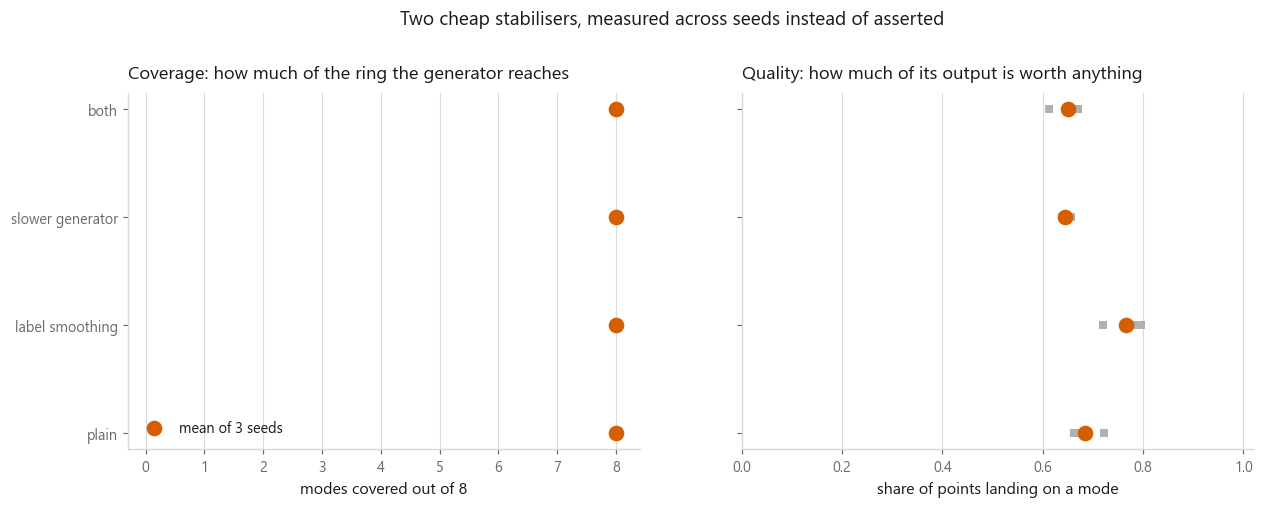

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.2), sharey=True)
positions = np.arange(len(CONFIGS))
names = list(CONFIGS)

panels = [(axes[0], "modes covered", "mean_covered", "modes covered out of 8",
           "Coverage: how much of the ring the generator reaches"),
          (axes[1], "quality", "mean_quality",
           "share of points landing on a mode",
           "Quality: how much of its output is worth anything")]

for ax, column, mean_column, xlabel, headline in panels:
    for i, name in enumerate(names):
        seeds_here = ablation[ablation["stabiliser"] == name][column]
        ax.scatter(seeds_here, [i] * len(seeds_here), s=34, linewidths=0,
                   color=style.NEUTRAL, marker=style.MARKERS[1], zorder=3)
    ax.scatter(per_config[mean_column], positions, s=105, linewidths=0,
               color=style.HIGHLIGHT, marker=style.MARKERS[0], zorder=4,
               label="mean of 3 seeds")
    ax.set_yticks(positions, names)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis="x")
    ax.grid(False, axis="y")
    style.title(ax, headline)

axes[0].set_xlim(-0.3, N_MODES + 0.4)
axes[1].set_xlim(0, 1.02)
axes[0].legend(loc="lower left")
fig.suptitle("Two cheap stabilisers, measured across seeds instead of asserted",
             x=0.5, y=1.06, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-stabilisers.png")

Read the grey points as much as the orange ones. Three seeds under a single
configuration landing far apart is itself a result: it says the configuration is
unreliable, which for a GAN is a more useful thing to know than its average. A
setting whose worst seed is close to its best is a setting you can run once and
trust.

What is missing from this list is the heavier machinery. Wasserstein GANs replace
the Jensen-Shannon divergence with an earth-mover distance, whose gradients do
not vanish when the two distributions barely overlap, and they come with a critic
loss that does correlate with sample quality, which repairs some of section 3.
Spectral normalisation constrains the discriminator's Lipschitz constant directly
and is close to free. Both belong in a longer treatment. The two here are the
ones that cost a line each.

### The image GAN, with expectations set first

Everything above holds because the ring can be measured. Fashion-MNIST cannot, at
least not in this notebook, so what follows is a demonstration and should be read
as one.

What to expect. A small fully connected GAN, on twelve thousand images, given a
hard cap of a few minutes, produces recognisable garment silhouettes with rough
edges and a certain amount of noise. It will not produce anything you would
mistake for a photograph, and it should not, because the budget is three orders
of magnitude below what published image GANs use. The samples below come from
noise vectors drawn once before training started, and the whole grid is shown.
Nothing is selected.

The architecture follows the usual conventions for this size: batch
normalisation in the generator, none in the discriminator, LeakyReLU on both
sides, dropout in the discriminator so it cannot memorise its way to certainty,
and a `tanh` output with the data rescaled to match it. Label smoothing carries
over from the section above, and the generator's learning rate sits below the
discriminator's.

In [16]:
train_set = datasets.fashion_mnist(train=True)
N_IMAGES = 12_000


def as_matrix(dataset, n_rows, seed=SEED):
    """The same subsample as 10-01 and 10-02, rescaled to [-1, 1].

    The rescale is not cosmetic. The generator ends in a tanh, so the data has to
    live in the same range or the discriminator can separate real from fake on
    the pixel range alone and the generator never learns anything about shape.
    """
    generator = torch.Generator().manual_seed(seed)
    picks = torch.randperm(len(dataset), generator=generator)[:n_rows].tolist()
    images = torch.stack([dataset[i][0] for i in picks]).view(len(picks), -1)
    return images * 2.0 - 1.0


X_images = as_matrix(train_set, N_IMAGES)
print(f"training matrix {tuple(X_images.shape)}, "
      f"pixel range {X_images.min():.1f} to {X_images.max():.1f}")

training matrix (12000, 784), pixel range -1.0 to 1.0


In [17]:
IMG_NOISE = 64
IMG_PIXELS = 784


class ImageGenerator(nn.Module):
    """Noise to a flat 784-vector in [-1, 1]."""

    def __init__(self, noise=IMG_NOISE, n_out=IMG_PIXELS):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, n_out), nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class ImageDiscriminator(nn.Module):
    """Dropout, no normalisation. A discriminator that is too sure of itself
    stops being a useful teacher, which is the same worry label smoothing has."""

    def __init__(self, n_in=IMG_PIXELS):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.net(x)


print(f"image generator     : {count(ImageGenerator()):,} parameters")
print(f"image discriminator : {count(ImageDiscriminator()):,} parameters")

image generator     : 551,952 parameters
image discriminator : 533,505 parameters


In [18]:
EPOCHS_IMG = 60
TIME_CAP = 170.0      # seconds; the loop stops on this, whichever comes first
BATCH_IMG = 128
SMOOTH_IMG = 0.9

torch.manual_seed(SEED)
G_img = ImageGenerator().to(device)
D_img = ImageDiscriminator().to(device)
opt_g = torch.optim.Adam(G_img.parameters(), lr=1.5e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(D_img.parameters(), lr=2e-4, betas=(0.5, 0.999))

X_device = X_images.to(device)
fixed_noise = torch.randn(64, IMG_NOISE, device=device)   # drawn before training

image_history = []
started = time.perf_counter()
epochs_done = 0

for epoch in range(EPOCHS_IMG):
    order = torch.randperm(len(X_device), device=device)
    running_g = running_d = batches = 0.0

    for start in range(0, len(X_device), BATCH_IMG):
        real = X_device[order[start:start + BATCH_IMG]]
        if len(real) < 2:                 # BatchNorm needs more than one row
            continue

        with torch.no_grad():
            fake = G_img(torch.randn(len(real), IMG_NOISE, device=device))
        out_real, out_fake = D_img(real), D_img(fake)
        d_loss = (bce(out_real, torch.full_like(out_real, SMOOTH_IMG))
                  + bce(out_fake, torch.zeros_like(out_fake)))
        opt_d.zero_grad(); d_loss.backward(); opt_d.step()

        out = D_img(G_img(torch.randn(len(real), IMG_NOISE, device=device)))
        g_loss = bce(out, torch.ones_like(out))
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()

        running_g += g_loss.item(); running_d += d_loss.item(); batches += 1

    epochs_done = epoch + 1
    image_history.append({"epoch": epochs_done, "generator": running_g / batches,
                          "discriminator": running_d / batches})
    if epochs_done % 10 == 0 or epochs_done == 1:
        print(f"epoch {epochs_done:>3}  generator {running_g / batches:.3f}  "
              f"discriminator {running_d / batches:.3f}  "
              f"{time.perf_counter() - started:.0f}s")
    if time.perf_counter() - started > TIME_CAP:
        break

print(f"\nstopped after {epochs_done} of {EPOCHS_IMG} epochs, "
      f"{time.perf_counter() - started:.0f} seconds on {device}")
print("as section 3 said, those two loss columns do not tell you how it went")

epoch   1  generator 1.051  discriminator 1.094  1s


epoch  10  generator 1.453  discriminator 1.071  13s


epoch  20  generator 1.490  discriminator 1.092  27s


epoch  30  generator 1.379  discriminator 1.121  40s


epoch  40  generator 1.364  discriminator 1.126  52s


epoch  50  generator 1.316  discriminator 1.141  64s


epoch  60  generator 1.294  discriminator 1.151  77s

stopped after 60 of 60 epochs, 77 seconds on cuda
as section 3 said, those two loss columns do not tell you how it went


In [19]:
G_img.eval()
with torch.no_grad():
    samples = ((G_img(fixed_noise) + 1) / 2).clamp(0, 1).cpu()

real01 = (X_images[:512] + 1) / 2


def sharpness(flat):
    """Mean absolute difference between horizontally adjacent pixels.

    A crude edge-energy measure, and enough to separate a blurred image from a
    sharp one, which is the comparison 10-02 left open.
    """
    grid = flat.view(-1, 28, 28)
    return (grid[:, :, 1:] - grid[:, :, :-1]).abs().mean().item()


padded = F.pad(real01.view(-1, 1, 28, 28), (1, 1, 1, 1), mode="replicate")
blurred = F.avg_pool2d(padded, 3, stride=1).view(-1, IMG_PIXELS)

print("edge energy (higher = sharper):")
print(f"  real images                : {sharpness(real01):.4f}")
print(f"  real images, 3x3 box blur  : {sharpness(blurred):.4f}")
print(f"  GAN samples                : {sharpness(samples):.4f}")
print()
print("per-pixel spread across the batch (near zero would mean collapse):")
print(f"  real images : {real01.std(dim=0).mean():.4f}")
print(f"  GAN samples : {samples.std(dim=0).mean():.4f}")

edge energy (higher = sharper):
  real images                : 0.0866
  real images, 3x3 box blur  : 0.0528
  GAN samples                : 0.1087

per-pixel spread across the batch (near zero would mean collapse):
  real images : 0.2762
  GAN samples : 0.2341


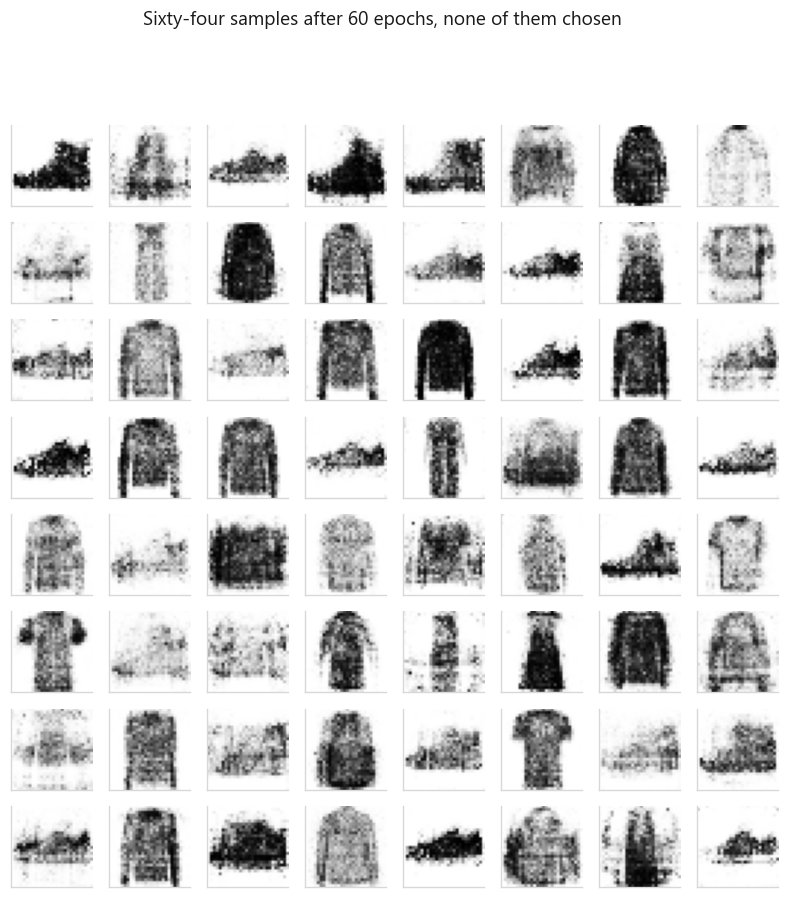

In [20]:
fig, axes = plt.subplots(8, 8, figsize=(9.0, 9.0))
for ax, image in zip(axes.ravel(), samples):
    ax.imshow(image.view(28, 28), cmap="gray_r", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle(f"Sixty-four samples after {epochs_done} epochs, none of them chosen",
             x=0.5, y=0.995, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-05-fashion-mnist-samples.png")

Some of those are clearly trousers, shoes and bags. Some are shapes that are
garment-adjacent and nothing more. That mixture is what a few minutes of training
a small fully connected GAN buys, and showing the whole grid rather than the best
eight is the only way the number of good ones stays meaningful.

The blurred-real row in the printout is there for the comparison
[10-02](../02-variational-autoencoders/) set up. A per-pixel likelihood pushes a
model toward the average of everything it is unsure about, and the box-blurred
images are what that looks like as a number. The GAN was never asked to minimise
a per-pixel distance, so averaging buys it nothing: a blurred garment is the
easiest thing in the world for a discriminator to catch, because real
Fashion-MNIST images have hard edges and blurred ones do not. Sharpness here is
not a bonus feature. It is what happens when the loss is a network that can
notice.

The per-pixel spread is the collapse check, carried over from the same notebook.
A GAN that had settled on one garment would show a spread near zero while its
losses looked entirely normal.

### The two models side by side

| | Variational autoencoder | Generative adversarial network |
|---|---|---|
| What it optimises | A lower bound on the data log-likelihood | Nothing. Two objectives in opposition, with no scalar being minimised |
| Training signal | One number that goes down and can be early-stopped on | Two numbers that move against each other and say nothing about sample quality |
| Typical failure | Posterior collapse: the code stops carrying information | Mode collapse: the generator stops carrying variety |
| How the failure is caught | Active dimensions, KL, reconstruction spread | Sample-based measurement only, which you have to build yourself |
| Samples | Blurry, because a per-pixel likelihood averages | Sharper, because averaging is what a discriminator catches first |
| Reliability | Trains the same way every time | Seed-dependent, and the ablation above shows by how much |
| Coverage of the data | Good. The likelihood term punishes ignoring parts of the data | Not guaranteed by anything in the objective |

The last row is the honest summary of the trade. A likelihood-based model pays a
price for every region of the data it fails to explain, so it explains all of
them, badly. An adversarial model pays no such price, so it can explain some of
them beautifully and forget the rest. The next chapter's diffusion models go back
to a likelihood-style objective and recover sharpness by a different route
entirely, which is why they took over.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Sharpness is the deliverable and you can afford to babysit training with a sample-based measurement |
| **Avoid it when** | You need coverage guarantees, a likelihood, or a training run that behaves the same way twice without supervision |
| **Generator loss** | `bce_with_logits(D(G(z)), ones)`, which is `-log D(G(z))`. Never the literal `log(1 - D(G(z)))` from the paper |
| **Discriminator loss** | `bce(D(real), 0.9) + bce(D(fake), 0)`. Detach the fake batch here, or the generator gets updated by the discriminator's optimiser |
| **Adam** | `betas=(0.5, 0.999)` on both. High first momentum makes an already oscillating system oscillate more |
| **Learning rates** | Give the discriminator the faster one. The theory assumes it is near-optimal; starving it is how section 4 broke training |
| **Label smoothing** | Real target 0.9, fake target 0.0. One-sided. Smoothing the fake side rewards the generator for ambiguity |
| **Architecture** | Normalisation in the generator, dropout and none in the discriminator, LeakyReLU on both sides, `tanh` output with data in [-1, 1] |
| **Diagnosis** | Sample-based, always. Coverage on a toy problem, FID or your own eyes on images. The loss is not a diagnostic |
| **Watch out** | Losses that look healthy are compatible with a generator producing one thing. Check the spread across a batch of samples every time |

## What to remember

1. A GAN replaces a likelihood with a second network. The generator never sees
   the data and learns only through the discriminator's gradient.
2. The minimax objective is minimised at the true distribution when the
   discriminator is optimal, which it never is. The gap between that assumption
   and gradient descent is where every practical problem lives.
3. The generator's original loss has a gradient proportional to `D(G(z))`, so it
   goes flat exactly when the generator is losing. The non-saturating form
   `-log D(G(z))` has the same optimum and the opposite gradient profile, and the
   table in section 2 gives the ratio.
4. GAN losses are not a measure of progress. They are scores in a game whose
   other player is moving, and section 3 shows the same generator loss sitting
   next to any coverage you like.
5. Mode collapse is the generator satisfying its objective by producing one thing
   well. Count it, do not describe it: section 4 measures coverage every fifty
   steps and the collapsing run's losses look ordinary throughout.
6. Label smoothing and a generator learning rate below the discriminator's are
   both one-line changes. The four-configuration table says what they bought
   here, and the spread across three seeds says how much to trust that.
7. Against the [variational autoencoder](../02-variational-autoencoders/): a GAN
   trades a trustworthy objective and guaranteed coverage for sharpness. Whether
   that is a good trade depends entirely on whether you have a way to measure
   what you gave up.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [10-04 Diffusion models](../04-diffusion-models/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#GAN` `#GenerativeAdversarialNetworks` `#GenerativeModels`
`#ModeCollapse` `#PyTorch` `#FashionMNIST` `#TrainingDynamics`
`#UnsupervisedLearning` `#MachineLearning` `#Python` `#MLTutorial` `#AI`